# Notebook 02 — Bloque Encoder completo y Codificación Posicional

**Bootcamp Bio-LLMs · Módulo 1 · Sesión 2 de 3**
Proyecto posdoctoral CICESE — Modelos de lenguaje para venómica integrativa de *Conus*.

---

## Objetivos

1. Implementar **codificación posicional sinusoidal** (Vaswani 2017, sec. 3.5) y discutir alternativas modernas (RoPE, ALiBi).
2. Construir el bloque encoder completo: `MHA → Add & Norm → FFN → Add & Norm`.
3. Apilar **2 capas** y validar el flujo dimensional sobre un mini-batch de secuencias toy de conotoxinas.
4. Discutir variantes pre-norm vs post-norm y su impacto en estabilidad de entrenamiento.

## Pre-requisito

* Haber completado el **Notebook 01**. Reutilizamos la clase `MultiHeadAttention` y la función `scaled_dot_product_attention`.

## 0. Imports y reuso del Notebook 01

Por pedagogía repetimos las clases base aquí; en un proyecto real las pondrías en un módulo `attention.py`.

In [1]:
# --- PATCH MPS (auto-inyectado) ---
import sys, os
_SCRIPTS = os.path.abspath(os.path.join(os.getcwd(), '..', 'scripts'))
if _SCRIPTS not in sys.path:
    sys.path.insert(0, _SCRIPTS)
from device_utils import get_device, set_seed  # noqa: E402
device = get_device()
# --- fin patch ---

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = get_device()


# --- Del Notebook 01 ---
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    attn = F.softmax(scores, dim=-1)
    return torch.matmul(attn, V), attn


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model, self.num_heads = d_model, num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, N, _ = x.shape
        Q = self.W_q(x).view(B, N, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, N, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, N, self.num_heads, self.d_k).transpose(1, 2)
        out, attn = scaled_dot_product_attention(Q, K, V, mask=mask)
        out = out.transpose(1, 2).contiguous().view(B, N, self.d_model)
        return self.dropout(self.W_o(out)), attn


[device_utils] PyTorch: 2.12.1
[device_utils] Dispositivo seleccionado: mps
[device_utils] MPS backend disponible (Apple Silicon).
[device_utils] PYTORCH_ENABLE_MPS_FALLBACK=1
[device_utils] PyTorch: 2.12.1
[device_utils] Dispositivo seleccionado: mps
[device_utils] MPS backend disponible (Apple Silicon).
[device_utils] PYTORCH_ENABLE_MPS_FALLBACK=1


## 1. Codificación posicional sinusoidal

El mecanismo de atención es **permutación-equivariante**: si reordenas los tokens de entrada, la salida se reordena de la misma forma. Esto es desastroso para secuencias biológicas — `ATG-CAA-GAT` no significa lo mismo que `GAT-CAA-ATG`.

La solución del paper original es **sumar un vector posicional** $PE_t$ al embedding del token $t$:

$$PE_{(t, 2i)} = \sin\!\left(\frac{t}{10000^{2i/d_{model}}}\right), \quad PE_{(t, 2i+1)} = \cos\!\left(\frac{t}{10000^{2i/d_{model}}}\right)$$

**Propiedades clave:**
* Determinístico (no aprende parámetros).
* Permite que el modelo extrapole a longitudes mayores a las vistas en entrenamiento (al menos en teoría — en la práctica funciona mal más allá de ~2× la longitud máxima de entrenamiento).
* La diferencia $PE_{t+k} - PE_t$ depende sólo de $k$, lo que facilita aprender posiciones relativas.

**Alternativas modernas (verás en Módulos 2-3):**
* **Embeddings aprendidos** (BERT/DNABERT): tabla `nn.Embedding(max_len, d_model)`. Simple pero no extrapola.
* **RoPE** (Rotary, ESM-2/NT-v2): rota Q y K en lugar de sumar. Mejor extrapolación.
* **ALiBi** (DNABERT-2): añade un sesgo lineal a los scores de atención. Sin parámetros, extrapola muy bien.

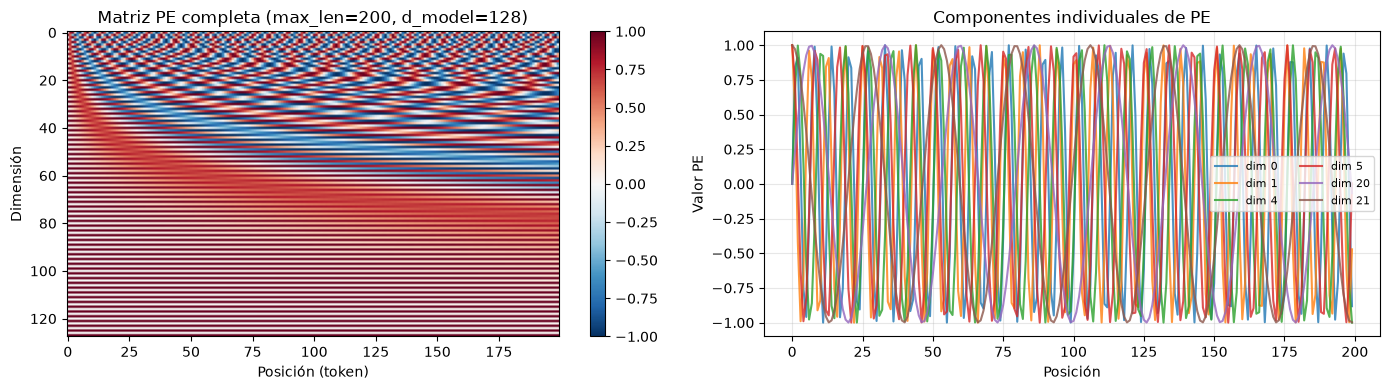

Observa cómo las dimensiones bajas oscilan rápido (longitudes de onda cortas)
y las altas oscilan despacio (longitudes de onda largas).
Esta combinación multi-escala permite codificar posiciones absolutas Y relativas.


In [2]:
class SinusoidalPositionalEncoding(nn.Module):
    """Codificación posicional sinusoidal del paper original (Vaswani 2017, sec. 3.5)."""

    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        # Precomputar la matriz (max_len, d_model)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )  # (d_model/2,)

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Registrar como buffer (no es parámetro entrenable pero se guarda con el state_dict)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        """x: (batch, seq_len, d_model) -> añade PE."""
        return x + self.pe[:, : x.size(1)]


# --- Visualizar la matriz PE ---
d_model = 128
pe_layer = SinusoidalPositionalEncoding(d_model, max_len=200)
pe_matrix = pe_layer.pe.squeeze(0).numpy()  # (200, d_model)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mapa de calor completo
im = axes[0].imshow(pe_matrix.T, cmap="RdBu_r", aspect="auto")
axes[0].set_xlabel("Posición (token)")
axes[0].set_ylabel("Dimensión")
axes[0].set_title(f"Matriz PE completa (max_len=200, d_model={d_model})")
plt.colorbar(im, ax=axes[0])

# Algunas dimensiones individuales
for dim in [0, 1, 4, 5, 20, 21]:
    axes[1].plot(pe_matrix[:, dim], label=f"dim {dim}", alpha=0.8)
axes[1].set_xlabel("Posición")
axes[1].set_ylabel("Valor PE")
axes[1].set_title("Componentes individuales de PE")
axes[1].legend(ncol=2, fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Observa cómo las dimensiones bajas oscilan rápido (longitudes de onda cortas)")
print("y las altas oscilan despacio (longitudes de onda largas).")
print("Esta combinación multi-escala permite codificar posiciones absolutas Y relativas.")

### Verificación de la propiedad de desplazamiento

Una propiedad útil: $PE_{t+k}$ puede expresarse como una transformación lineal de $PE_t$ que **no depende de $t$**. Esto facilita que la atención aprenda "atender al token 3 posiciones atrás" independientemente de dónde esté.

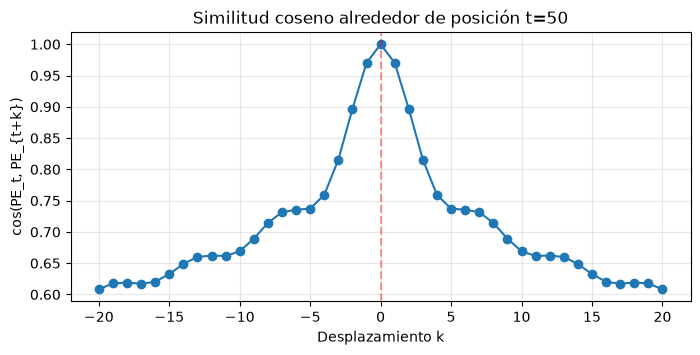


Similitud cos(PE_t, PE_{t+5}) para diferentes t:
  t= 10 -> 0.7373
  t= 30 -> 0.7373
  t= 50 -> 0.7373
  t= 80 -> 0.7373
  t=120 -> 0.7373

→ Aproximadamente constante: confirma invarianza traslacional.


In [3]:
# Verificar empíricamente: la similitud coseno entre PE_t y PE_{t+k}
# debe depender sólo de k, no de t.
from numpy.linalg import norm

def cosine(a, b):
    return (a @ b) / (norm(a) * norm(b) + 1e-9)

t_pivot = 50
ks = list(range(-20, 21))
sims = [cosine(pe_matrix[t_pivot], pe_matrix[t_pivot + k]) for k in ks]

plt.figure(figsize=(8, 3.5))
plt.plot(ks, sims, "o-")
plt.axvline(0, color="red", ls="--", alpha=0.4)
plt.xlabel("Desplazamiento k")
plt.ylabel("cos(PE_t, PE_{t+k})")
plt.title(f"Similitud coseno alrededor de posición t={t_pivot}")
plt.grid(alpha=0.3)
plt.show()

# Comprobar invarianza respecto a t
print("\nSimilitud cos(PE_t, PE_{t+5}) para diferentes t:")
for t in [10, 30, 50, 80, 120]:
    print(f"  t={t:>3} -> {cosine(pe_matrix[t], pe_matrix[t+5]):.4f}")
print("\n→ Aproximadamente constante: confirma invarianza traslacional.")

## 2. La sub-capa Feed-Forward (FFN)

Después de la atención, cada posición pasa por una MLP **independiente** (idéntica para todas las posiciones, pero sin mezclarlas):

$$\text{FFN}(x) = \text{Linear}_2(\text{Activation}(\text{Linear}_1(x)))$$

* Vaswani 2017 usa ReLU. DNABERT/BERT usan GELU. Modelos modernos (LLaMA, ESM-2) usan SwiGLU.
* Dimensión interna típica: $d_{ff} = 4 \cdot d_{model}$.

**Interpretación.** La atención mezcla información *entre* tokens. La FFN procesa cada token *en su propio espacio*, refinando la representación. Ambas son necesarias: sin FFN, el modelo sería puramente lineal entre tokens; sin atención, sería un MLP posición-a-posición sin contexto.

In [4]:
class PositionwiseFeedForward(nn.Module):
    """FFN del Transformer: dos linears con activación en medio."""

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.0,
                 activation: str = "gelu"):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

        if activation == "relu":
            self.act = F.relu
        elif activation == "gelu":
            self.act = F.gelu  # Como BERT/DNABERT
        else:
            raise ValueError(f"Activación no soportada: {activation}")

    def forward(self, x):
        return self.linear2(self.dropout(self.act(self.linear1(x))))


# --- Test ---
ffn = PositionwiseFeedForward(d_model=128, d_ff=512)
x_demo = torch.randn(2, 10, 128)
print(f"Entrada FFN  : {tuple(x_demo.shape)}")
print(f"Salida FFN   : {tuple(ffn(x_demo).shape)}")
print(f"Parámetros   : {sum(p.numel() for p in ffn.parameters()):,}")
print(f"            ~ d_model * d_ff * 2 = {128*512*2:,}")

Entrada FFN  : (2, 10, 128)
Salida FFN   : (2, 10, 128)
Parámetros   : 131,712
            ~ d_model * d_ff * 2 = 131,072


## 3. El bloque encoder completo

Cada bloque encoder consiste en dos sub-capas, cada una con conexión residual y LayerNorm:

```
              ┌──────────────────────────────────┐
              │                                  │
   x ────►   MHA   ──► Dropout ──► (+) ──► LayerNorm ──┐
                                    ▲                  │
                                    └──────────────────┘
                                                       │
              ┌─────────────────────────────────────────┘
              │
              ▼
             FFN   ──► Dropout ──► (+) ──► LayerNorm ──► out
                                    ▲
                                    └────────┐
                                             │ (residual desde la entrada del FFN)
```

### Post-norm vs Pre-norm

| Esquema | Fórmula | Comentario |
|---|---|---|
| **Post-norm** (Vaswani 2017, BERT, DNABERT) | $x \leftarrow \text{LN}(x + \text{Sublayer}(x))$ | Más expresivo pero inestable en >12 capas — requiere *learning rate warmup* |
| **Pre-norm** (GPT-2, LLaMA, ESM-2, NT-v2) | $x \leftarrow x + \text{Sublayer}(\text{LN}(x))$ | Más estable, escala mejor a 100+ capas — el estándar moderno |

Implementaremos **ambos** para que puedas comparar.

In [5]:
class EncoderLayer(nn.Module):
    """Una capa del encoder. Permite alternar entre post-norm y pre-norm."""

    def __init__(self, d_model: int, num_heads: int, d_ff: int,
                 dropout: float = 0.1, norm_first: bool = True):
        super().__init__()
        self.norm_first = norm_first

        self.mha = MultiHeadAttention(d_model, num_heads, dropout=dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout=dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        if self.norm_first:
            # PRE-NORM (estándar moderno)
            attn_out, attn_weights = self.mha(self.norm1(x), mask=mask)
            x = x + self.dropout(attn_out)
            x = x + self.dropout(self.ffn(self.norm2(x)))
        else:
            # POST-NORM (paper original)
            attn_out, attn_weights = self.mha(x, mask=mask)
            x = self.norm1(x + self.dropout(attn_out))
            x = self.norm2(x + self.dropout(self.ffn(x)))

        return x, attn_weights


# --- Test ---
layer = EncoderLayer(d_model=128, num_heads=8, d_ff=512, norm_first=True)
x_demo = torch.randn(2, 10, 128)
out, attn = layer(x_demo)
print(f"Entrada      : {tuple(x_demo.shape)}")
print(f"Salida       : {tuple(out.shape)}     (esperado: (2, 10, 128))")
print(f"Atención     : {tuple(attn.shape)}    (esperado: (2, 8, 10, 10))")
print(f"Parámetros   : {sum(p.numel() for p in layer.parameters()):,}")

Entrada      : (2, 10, 128)
Salida       : (2, 10, 128)     (esperado: (2, 10, 128))
Atención     : (2, 8, 10, 10)    (esperado: (2, 8, 10, 10))
Parámetros   : 197,760


## 4. Encoder completo con 2 capas apiladas

Combinamos todo en un encoder ejecutable. Será la base que en el Notebook 03 conectaremos a una cabeza MLM.

In [6]:
class TinyEncoder(nn.Module):
    """
    Encoder mínimo del estilo BERT/DNABERT:
    embedding + positional encoding + N capas de encoder.
    """

    def __init__(self, vocab_size: int, d_model: int = 128, num_heads: int = 4,
                 num_layers: int = 2, d_ff: int = 512, max_len: int = 512,
                 dropout: float = 0.1, pad_id: int = 0):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len=max_len)
        self.embed_dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout=dropout, norm_first=True)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)  # común en pre-norm

    def make_padding_mask(self, token_ids):
        """(B, N) -> (B, 1, 1, N) con True donde hay padding."""
        return (token_ids == self.pad_id).unsqueeze(1).unsqueeze(2)

    def forward(self, token_ids, return_attentions: bool = False):
        # 1. Embedding + escalado (Vaswani 2017 sec. 3.4)
        x = self.token_embedding(token_ids) * math.sqrt(self.d_model)
        # 2. Codificación posicional
        x = self.embed_dropout(self.pos_encoding(x))
        # 3. Máscara de padding (broadcast-friendly)
        mask = self.make_padding_mask(token_ids)
        # 4. Stack de capas
        all_attentions = []
        for layer in self.layers:
            x, attn = layer(x, mask=mask)
            if return_attentions:
                all_attentions.append(attn)
        # 5. Norm final (pre-norm)
        x = self.final_norm(x)

        if return_attentions:
            return x, all_attentions
        return x


# --- Test: forward sobre un mini-batch sintético ---
vocab_size = 25      # 20 aminoácidos + 5 tokens especiales
encoder = TinyEncoder(vocab_size=vocab_size, d_model=128, num_heads=4,
                      num_layers=2, d_ff=512)

# Batch sintético: dos secuencias de 12 tokens (la segunda con padding al final)
batch = torch.tensor([
    [5, 8, 8, 14, 16, 5, 8, 12, 18, 19, 8, 8],   # secuencia completa
    [5, 8, 8, 14, 16, 5, 8, 12,  0,  0, 0, 0],   # con padding (id=0)
])

out, attns = encoder(batch, return_attentions=True)
print(f"Salida del encoder : {tuple(out.shape)}      (esperado: (2, 12, 128))")
print(f"Nº de matrices attn: {len(attns)}            (esperado: 2 capas)")
print(f"Forma de cada attn : {tuple(attns[0].shape)}  (esperado: (2, 4, 12, 12))")

# Conteo de parámetros
n_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f"\nTotal parámetros entrenables: {n_params:,}  (~{n_params/1e6:.2f} M)")

Salida del encoder : (2, 12, 128)      (esperado: (2, 12, 128))
Nº de matrices attn: 2            (esperado: 2 capas)
Forma de cada attn : (2, 4, 12, 12)  (esperado: (2, 4, 12, 12))

Total parámetros entrenables: 398,976  (~0.40 M)


## 5. Sanity check: ¿los gradientes fluyen?

Antes de pasar al Notebook 03 (pre-entrenamiento), verificamos que los gradientes lleguen a todas las capas. Un bug clásico al implementar Transformers desde cero es perder gradientes en alguna sublayer; este test lo cazaría.

In [7]:
# Forward + backward dummy
encoder.train()
out = encoder(batch)
loss = out.pow(2).mean()  # loss arbitraria sólo para tener un gradiente
loss.backward()

# Inspeccionar gradientes por capa
print(f"{'Capa':<50} {'shape':<22} {'||grad||':>12}")
print("-" * 88)
for name, param in encoder.named_parameters():
    if param.grad is not None:
        gnorm = param.grad.norm().item()
        flag = "✓" if gnorm > 1e-8 else "✗ (sin gradiente!)"
        print(f"{name:<50} {str(tuple(param.shape)):<22} {gnorm:>12.4e}  {flag}")
    else:
        print(f"{name:<50} <sin gradiente>")

print("\nTodos los parámetros deben tener gradiente > 0 (excepto padding_idx, que es esperado).")

Capa                                               shape                      ||grad||
----------------------------------------------------------------------------------------
token_embedding.weight                             (25, 128)                2.1136e-07  ✓
layers.0.mha.W_q.weight                            (128, 128)               6.1567e-07  ✓
layers.0.mha.W_k.weight                            (128, 128)               6.7141e-07  ✓
layers.0.mha.W_v.weight                            (128, 128)               2.4559e-06  ✓
layers.0.mha.W_o.weight                            (128, 128)               2.8140e-06  ✓
layers.0.ffn.linear1.weight                        (512, 128)               3.1411e-06  ✓
layers.0.ffn.linear1.bias                          (512,)                   3.0318e-07  ✓
layers.0.ffn.linear2.weight                        (128, 512)               5.7198e-06  ✓
layers.0.ffn.linear2.bias                          (128,)                   8.0014e-07  ✓
layers.0.norm1

## 6. Demostración empírica: pre-norm vs post-norm

Construimos dos encoders idénticos salvo por `norm_first`, los entrenamos sobre la misma tarea sintética unas pocas iteraciones, y observamos la curva de pérdida.

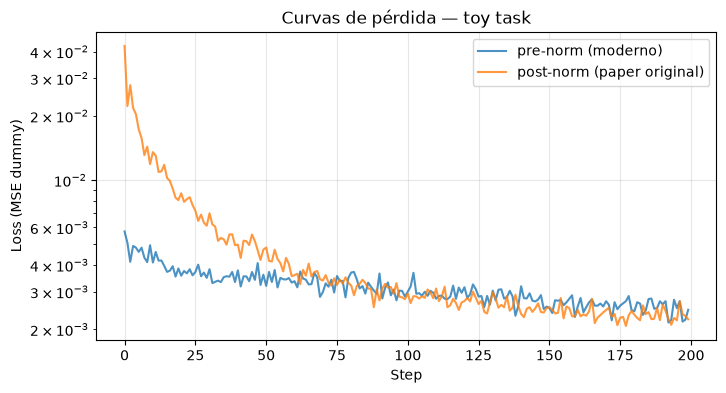

Con 2 capas la diferencia es modesta. Con >12 capas y sin warmup,
post-norm suele divergir mientras pre-norm permanece estable.


In [8]:
def quick_train(encoder, n_steps=200, lr=1e-3):
    """Entrenamiento dummy: predecir la suma de embeddings."""
    encoder.train()
    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)
    losses = []
    for step in range(n_steps):
        # Batch aleatorio
        tokens = torch.randint(5, vocab_size, (8, 32))  # batch=8, len=32
        target = encoder.token_embedding(tokens).mean(dim=1)  # (B, d_model)

        out = encoder(tokens)
        pred = out.mean(dim=1)  # (B, d_model)
        loss = F.mse_loss(pred, target.detach())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(loss.item())
    return losses


# Reentrenar ambos desde semilla idéntica
torch.manual_seed(0)
enc_pre = TinyEncoder(vocab_size, num_layers=2)
for l in enc_pre.layers: l.norm_first = True

torch.manual_seed(0)
enc_post = TinyEncoder(vocab_size, num_layers=2)
for l in enc_post.layers: l.norm_first = False

losses_pre = quick_train(enc_pre)
losses_post = quick_train(enc_post)

plt.figure(figsize=(8, 4))
plt.plot(losses_pre, label="pre-norm (moderno)", alpha=0.8)
plt.plot(losses_post, label="post-norm (paper original)", alpha=0.8)
plt.xlabel("Step")
plt.ylabel("Loss (MSE dummy)")
plt.title("Curvas de pérdida — toy task")
plt.legend()
plt.yscale("log")
plt.grid(alpha=0.3)
plt.show()

print("Con 2 capas la diferencia es modesta. Con >12 capas y sin warmup,")
print("post-norm suele divergir mientras pre-norm permanece estable.")

## 7. Ejercicios

### 7.1 — Embeddings posicionales aprendidos
Sustituye `SinusoidalPositionalEncoding` por una `nn.Embedding(max_len, d_model)` aprendida (como BERT/DNABERT). Compara el comportamiento en `quick_train`.

### 7.2 — Contar FLOPs
Estima los FLOPs del forward pass de `TinyEncoder` con `seq_len=512, d_model=768, num_heads=12, num_layers=12, d_ff=3072` (configuración DNABERT-base). Compara con el conteo de parámetros — para Transformers, FLOPs ≈ 2 · params · tokens (regla de Kaplan et al. 2020).

### 7.3 — Iniciar bien para extrapolación
Lee la sección de RoPE en el paper del Nucleotide Transformer (Dalla-Torre et al. 2023, suppl. material). Implementa RoPE sustituyendo la suma de PE por una rotación de Q y K. ¿Por qué permite extrapolar a contextos más largos?

---

## 8. Próximo notebook

**Notebook 03 — Pre-entrenamiento MLM sobre CDS de conotoxinas**. Conectaremos este encoder a una cabeza de predicción de codones enmascarados, generaremos un mini-corpus sintético de CDS de *Conus*, entrenaremos y reportaremos perplejidad.

In [9]:
print(f"PyTorch  : {torch.__version__}")
print(f"Encoder  : {sum(p.numel() for p in encoder.parameters()):,} parámetros")
print("Listo para el Notebook 03.")

PyTorch  : 2.12.1
Encoder  : 398,976 parámetros
Listo para el Notebook 03.
